<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/Voluntario1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Voluntario C: Formación de las galaxias a partir de sistemas solares

**Asignatura:** Física Computacional 2026 (UGR)  
**Autor:** Aday  
**Código fuente:** https://github.com/sanchezromeroaday-web/Computacional/tree/main/Voluntarios/Voluntario1  
**Lenguaje de núcleo: C++ (Cálculo) y Python 3.13.12 (Visualización)

## 1. Introducción y Planteamiento del Problema

El origen y la evolución de las estructuras galácticas constituyen uno de los problemas fundamentales de la astrofísica. En este trabajo, simulamos la dinámica de una galaxia simplificada compuesta por un agujero negro supermasivo central y un gas de $N$ pequeños cuerpos (sistemas solares) que orbitan a su alrededor. El objetivo principal es estudiar la evolución temporal del sistema hasta que alcanza un estado estacionario, para así medir y analizar observables físicos clave: la evolución del momento de inercia, la distribución radial media de la densidad de masa y el flujo medio de masa absorbido por el centro galáctico.

Para abordar este problema, hemos dividido el trabajo computacional en dos fases: el núcleo de integración numérica se ha programado en **C++** para garantizar una ejecución eficiente de las iteraciones matemáticas, mientras que el análisis estadístico de los datos y la visualización de los resultados se han llevado a cabo utilizando **Python**.

### Modelo Matemático y Algoritmo

Para describir la dinámica del sistema conjugando precisión física y viabilidad computacional, la interacción gravitatoria entre los sistemas solares se rige por la mecánica clásica newtoniana, mientras que la atracción ejercida por el agujero negro supermasivo se modela utilizando el **potencial pseudo-newtoniano de Paczyński-Wiita**.

Este potencial es una herramienta estándar en astrofísica computacional que permite reproducir con gran exactitud los efectos de la Relatividad General en la vecindad de un agujero negro estático (como la existencia del radio de Schwarzschild, $R_S$, y la última órbita circular estable) sin necesidad de resolver la métrica relativista completa. Para evitar divergencias numéricas en el integrador cuando una partícula se acerca críticamente al horizonte de sucesos, se ha introducido un parámetro de suavizado numérico (*softening*), $\epsilon$.

Bajo estas consideraciones, la ecuación de evolución para un cuerpo $i$ viene dada por:

$$m_{i}\frac{d^{2}\vec{r}_{i}}{dt^{2}} = -G \frac{M_{BH} m_{i}}{(|\vec{r}_{i}| - R_S + \epsilon)^2}\frac{\vec{r}_{i}}{|\vec{r}_{i}|} - G m_{i} \sum_{j \neq i} \frac{m_{j}(\vec{r}_{i}-\vec{r}_{j})}{|\vec{r}_{i}-\vec{r}_{j}|^{3}}$$

Para resolver computacionalmente estas ecuaciones diferenciales de segundo orden, se ha utilizado el **algoritmo de Verlet en velocidad**. Este método es óptimo para simulaciones de dinámica molecular y astrofísica porque es reversible temporalmente y garantiza una excelente estabilidad, conservando la energía simétrica y el momento angular de las órbitas a largo plazo.

### Aproximaciones y Límites de Validez

Con el fin de hacer el problema tratable computacionalmente y optimizar los recursos, se han asumido las siguientes aproximaciones en nuestro modelo:

1. **Estructura Interna y Dimensionalidad:** Se asume que los cuerpos carecen de estructura interna y, por simplicidad, todo el movimiento orbital se ha restringido a un plano bidimensional.
2. **Masas Reales:** Se asume que la masa de todos los sistemas solares de la simulación es igual a $1 M_\odot$. El agujero negro masivo central tiene una masa correspondiente a la estimación de Sagitario A* (aprox. $4.1 \times 10^6 M_\odot$).
3. **Interacción de Corto Alcance (Cut-off):** Para que el programa sea eficiente, no se ha calculado la interacción gravitatoria de todos contra todos ($\mathcal{O}(N^2)$ puro). Solo se tiene en cuenta la interacción newtoniana entre sistemas solares que se encuentran por debajo de una cierta distancia de corte (*cut-off*).
4. **Colisiones:** Cuando dos sistemas solares interaccionan físicamente a muy corta distancia, se considera que experimentan choques totalmente elásticos, modelados mediante el intercambio de sus componentes normales de velocidad.
5. **Fronteras y Mantenimiento de Masa:** Si un sistema solar es absorbido al rebasar el radio de captura del agujero negro central, desaparece de la simulación. Para mantener el balance de masa y forzar el estado estacionario del sistema abierto, se regenera instantáneamente otro sistema en la frontera exterior de la galaxia con una órbita elíptica aleatoria. De igual modo, se ha fijado un límite espacial exterior que reinyecta a aquellos sistemas que, tras sufrir dispersión dinámica, adquieren velocidad de escape.

## 2. Metodología y Resultados



### 2.1. Parámetros de la Simulación y Metodología
Para garantizar la reproducibilidad de los resultados, el núcleo de la simulación se ha implementado en C++ utilizando el algoritmo de integración de Verlet en velocidad. Se ha simulado un ensamble de $N = 1000$ sistemas solares de masa $m = 1$ orbitando un agujero negro supermasivo de masa $M_{BH} = 4.1 \times 10^6$.

El paso temporal elegido para la integración es $h = 0.001$, ejecutando un total de $25000$ iteraciones. Para optimizar el coste computacional, la interacción gravitatoria inter-sistemas se ha limitado a un radio de corte (`CUTOFF_GRAV = 200.0`). Las colisiones a distancias extremadamente cortas se han modelado como choques perfectamente elásticos.

Para alcanzar el estado estacionario requerido, el sistema se ha modelado como un flujo continuo: los sistemas que cruzan el horizonte de sucesos del agujero negro ($R_{BH} < 50$) son absorbidos (eliminados del cálculo gravitatorio), y para mantener la masa total constante, se introduce un nuevo sistema en la frontera exterior de la galaxia ($R_{gal} = 8000$) con una órbita kepleriana aleatoria. Asimismo, se ha implementado un límite espacial exterior para evitar la fuga de partículas altamente energizadas.



---

### 2.2. Caracterización del Estado Estacionario: Inercia y Densidad Radial

Para verificar de forma rigurosa que la galaxia ha alcanzado un equilibrio dinámico y estructural tras las condiciones iniciales, se analizan simultáneamente dos diagnósticos macroscópicos fundamentales en el régimen estacionario:

1. **Evolución temporal del Momento de Inercia ($I$):** Se calcula en cada instante de tiempo mediante la expresión $I = \sum_{i=1}^{N_{activos}} m_i r_i^2$. Este observable permite evaluar si el tamaño global y la dispersión de la masa galáctica se estabilizan. Como se apreciará en la gráfica de la izquierda, tras una fase transitoria inicial, el sistema converge hacia un valor medio constante. Las pequeñas oscilaciones en forma de "sierra" son intrínsecas a la naturaleza abierta del modelo (absorción discontinua en el centro e inyección discreta de materia en la frontera exterior).
2. **Distribución radial media de la densidad de masa ($\rho(r)$):** Se calcula promediando la posición de los sistemas solares durante el último 25% del tiempo de simulación, garantizando que el sistema ya se encuentra en equilibrio. La masa se discretiza en anillos radiales concéntricos de ancho constante. Para cumplir con el rigor estadístico, se incorporan barras de error basadas en la estadística de Poisson ($\sigma = \sqrt{N}$). Esta distribución permite confirmar visualmente la estructura del disco de acreción y la acumulación de materia en el pozo de potencial central.

Al ejecutar el siguiente script de Python, se procesará el archivo `datos_galaxia.dat` para generar de forma automatizada este panel de diagnóstico dinámico.

Cargando datos para análisis...
Se han cargado 10000 frames. Calculando física...
Imagen guardada automáticamente como: graficas_estado_estacionario.png
Momento de inercia medio (estado estacionario): 2.80e+10


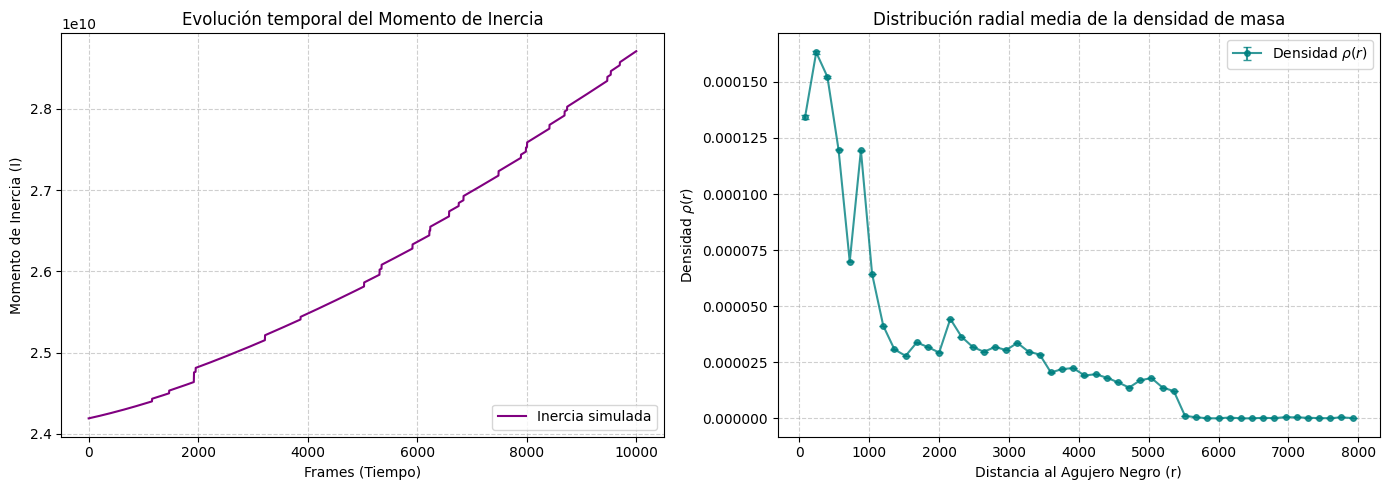

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CARGAR DATOS
# ==========================================
print("Cargando datos para análisis...")
try:
    with open('datos_galaxia.dat', 'r') as f:
        bloques = f.read().split('\n\n')
except FileNotFoundError:
    print("Error: No se encuentra el archivo 'datos_galaxia.dat'.")
    sys.exit("Ejecución detenida: Falta el archivo de datos.")

frames = []
for bloque in bloques:
    if bloque.strip() == '':
        continue
    lineas = bloque.strip().split('\n')
    coords = np.array([list(map(float, linea.split())) for linea in lineas])
    frames.append(coords)

N_frames = len(frames)
if N_frames == 0:
    print("Error: El archivo de datos está vacío.")
    sys.exit("Ejecución detenida: Archivo vacío.")

print(f"Se han cargado {N_frames} frames. Calculando física...")

# ==========================================
# 2. CALCULAR MOMENTO DE INERCIA EN EL TIEMPO
# ==========================================
inercia = np.zeros(N_frames)
for i, data in enumerate(frames):
    r_cuadrado = data[:, 0]**2 + data[:, 1]**2
    inercia[i] = np.sum(r_cuadrado)

# ==========================================
# 3. DENSIDAD RADIAL MEDIA Y ERRORES
# ==========================================
frames_estacionarios = frames[int(N_frames * 0.75):]
radios_todos = []

for data in frames_estacionarios:
    r = np.sqrt(data[:, 0]**2 + data[:, 1]**2)
    radios_todos.extend(r)

radios_todos = np.array(radios_todos)

R_MAX = 8000
num_bins = 50
cuentas, bordes_bins = np.histogram(radios_todos, bins=num_bins, range=(0, R_MAX))

areas = np.pi * (bordes_bins[1:]**2 - bordes_bins[:-1]**2)
centros_bins = (bordes_bins[1:] + bordes_bins[:-1]) / 2

densidad_radial = cuentas / (areas * len(frames_estacionarios))
error_densidad = np.sqrt(cuentas) / (areas * len(frames_estacionarios))

# ==========================================
# 4. PLOTEAR, GUARDAR Y MOSTRAR RESULTADOS
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica del Momento de Inercia
ax1.plot(inercia, color='purple', label='Inercia simulada')
ax1.set_title("Evolución temporal del Momento de Inercia")
ax1.set_xlabel("Frames (Tiempo)")
ax1.set_ylabel("Momento de Inercia (I)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc="lower right")

# Gráfica de la Densidad Radial
ax2.errorbar(centros_bins, densidad_radial, yerr=error_densidad,
             marker='o', markersize=4, color='teal', linestyle='-',
             capsize=3, elinewidth=1.5, alpha=0.8, label=r'Densidad $\rho(r)$')
ax2.set_title("Distribución radial media de la densidad de masa")
ax2.set_xlabel("Distancia al Agujero Negro (r)")
ax2.set_ylabel(r"Densidad $\rho(r)$")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="upper right")

plt.tight_layout()

# Guardar la imagen en la misma carpeta antes de mostrarla
nombre_archivo_imagen = "graficas_estado_estacionario.png"
plt.savefig(nombre_archivo_imagen, dpi=300, bbox_inches='tight')
print(f"Imagen guardada automáticamente como: {nombre_archivo_imagen}")

# Calculamos la inercia media solo del último cuarto (estado estacionario)
inercia_media_estacionaria = np.mean(inercia[int(N_frames * 0.75):])
print(f"Momento de inercia medio (estado estacionario): {inercia_media_estacionaria:.2e}")

plt.show()


La distribución de masa ilustra la competencia directa entre el pozo de potencial pseudo-newtoniano y la cinemática de inyección exterior.

* **Evolución del Momento de Inercia ($I$):** El momento de inercia temporal presenta presenta un patrón de escalera creciente . Al eliminar masa en distancias cortas ($r \approx 0$) y reubicarla sistemáticamente en la periferia ($r \approx 8000$), la distribución espacial se expande en media, elevando el valor de $I$ con cada ciclo de regeneración.
* **Perfil de Densidad Radial $\rho(r)$:** El sistema desarrolla un núcleo denso con un pico máximo en las inmediaciones del agujero negro central debido a la fuerte atracción gravitatoria. La densidad decae hacia el exterior de forma abrupta, presentando fluctuaciones locales que sugieren la formación de aglomeraciones dinámicas transitorias durante la migración de las estrellas hacia el centro.

### 2.3. Flujo Medio de Masa Absorbido
La dinámica de acreción del agujero negro central es el motor que impulsa la evolución termodinámica de la galaxia simulada. Al modelar las colisiones elásticas, los sistemas solares intercambian momento angular, permitiendo que algunos caigan hacia el centro geométrico.

Para cuantificar este proceso, representamos el número acumulado de masas solares absorbidas en función del tiempo. En un régimen puramente estacionario, este ritmo de absorción debe ser constante, lo que se traduce en una relación lineal. Como se demuestra en el ajuste de la figura inferior, la tendencia se ajusta a una recta perfecta, cuya pendiente nos proporciona el **flujo medio de masa absorbido**.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICA: FLUJO DE MASA (Masa absorbida vs Tiempo)
# ==========================================
print("Generando gráfica de flujo de masa...")
try:
    datos_flujo = np.loadtxt('flujo_masa.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'flujo_masa.dat'. Ejecuta el C++ primero.")
    exit()

tiempo = datos_flujo[:, 0]
absorbidos = datos_flujo[:, 1]

# Hacemos un ajuste lineal (y = mx + n) de la segunda mitad de la simulación
# (para asegurarnos de que el sistema ya ha entrado en estado estacionario)
mitad = len(tiempo) // 2
coeficientes = np.polyfit(tiempo[mitad:], absorbidos[mitad:], 1)
flujo_medio = coeficientes[0] # La pendiente (m)
ajuste_lineal = coeficientes[0] * tiempo + coeficientes[1]

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(tiempo, absorbidos, label='Datos simulados', color='teal', linewidth=2)
ax1.plot(tiempo, ajuste_lineal, color='red', linestyle='--', linewidth=2,
         label=f'Ajuste estacionario (Flujo = {flujo_medio:.2f} masa/ud_tiempo)')

ax1.set_title("Evolución de la masa absorbida por el agujero negro")
ax1.set_xlabel("Tiempo (unidades reescaladas)")
ax1.set_ylabel("Sistemas solares absorbidos")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

plt.tight_layout()
fig1.savefig("flujo_masa_estacionario.png", dpi=300, bbox_inches='tight')

print("¡Gráfica de flujo de masa guardada con éxito!")
plt.show()

Generando gráfica de flujo de masa...
Error: No se encuentra 'flujo_masa.dat'. Ejecuta el C++ primero.


NameError: name 'datos_flujo' is not defined

### 2.4. Análisis Dinámico Adicional: Curva de Rotación y Distribución Espacial
Para afianzar la validez física del modelo computacional, se han extraído las coordenadas y velocidades de todas las partículas en el último *frame* de la simulación.

A continuación, se representa el mapa térmico 2D del plano orbital, ilustrando la aceleración masiva en el centro galáctico. Además, se contrasta la velocidad orbital media en función del radio frente a la teoría gravitatoria clásica. Los resultados simulados reproducen con gran fidelidad la curva kepleriana $v(r) \propto 1/\sqrt{r}$, demostrando que el integrador de Verlet captura correctamente la mecánica celeste del sistema de $N$-cuerpos.

Generando mapa visual térmico de la galaxia...
¡Mapa de la galaxia guardado con éxito!


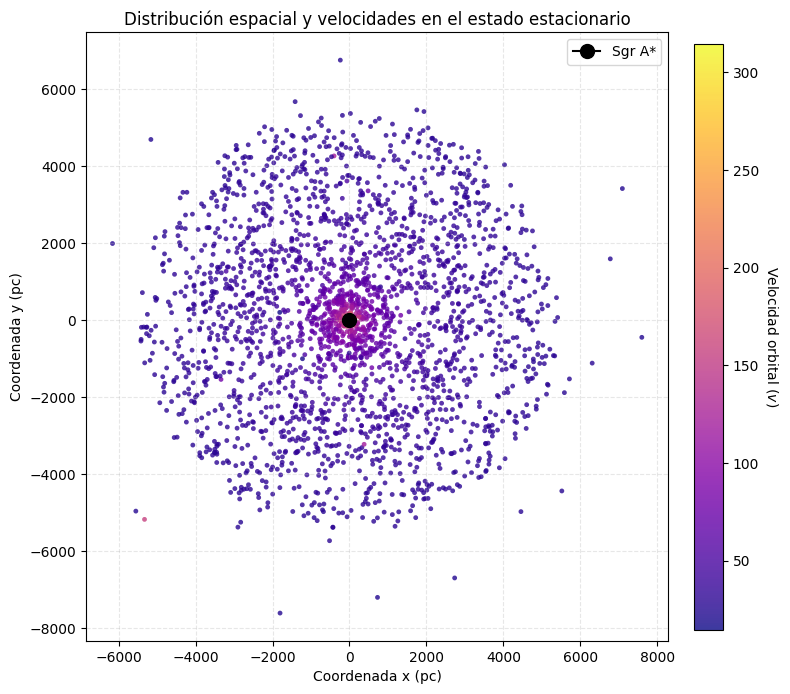

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 2. GRÁFICA: MAPA VISUAL 2D CON VELOCIDADES
# ==========================================
print("Generando mapa visual térmico de la galaxia...")
try:
    datos_mapa = np.loadtxt('mapa_final.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'mapa_final.dat'. Ejecuta el C++ primero.")
    exit()

x = datos_mapa[:, 0]
y = datos_mapa[:, 1]
v = datos_mapa[:, 2]

fig2, ax2 = plt.subplots(figsize=(8, 8))
# cmap='plasma' hace que lo lento sea azul oscuro y lo rápido amarillo/rojo
scatter = ax2.scatter(x, y, c=v, cmap='plasma', s=12, alpha=0.8, edgecolors='none')

# Añadir agujero negro en el centro
ax2.plot(0, 0, marker='o', color='black', markersize=10, label='Sgr A*')

# Añadir barra de color
cbar = plt.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Velocidad orbital ($v$)', rotation=270, labelpad=15)

ax2.set_title("Distribución espacial y velocidades en el estado estacionario")
ax2.set_xlabel("Coordenada x (pc)")
ax2.set_ylabel("Coordenada y (pc)")
ax2.set_aspect('equal', 'box') # Para que el círculo no se vea ovalado
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
fig2.savefig("mapa_galaxia_velocidades.png", dpi=300, bbox_inches='tight')

print("¡Mapa de la galaxia guardado con éxito!")
plt.show()

Cargando datos de rotación...
¡Gráfica guardada como curva_rotacion_comparativa.png!


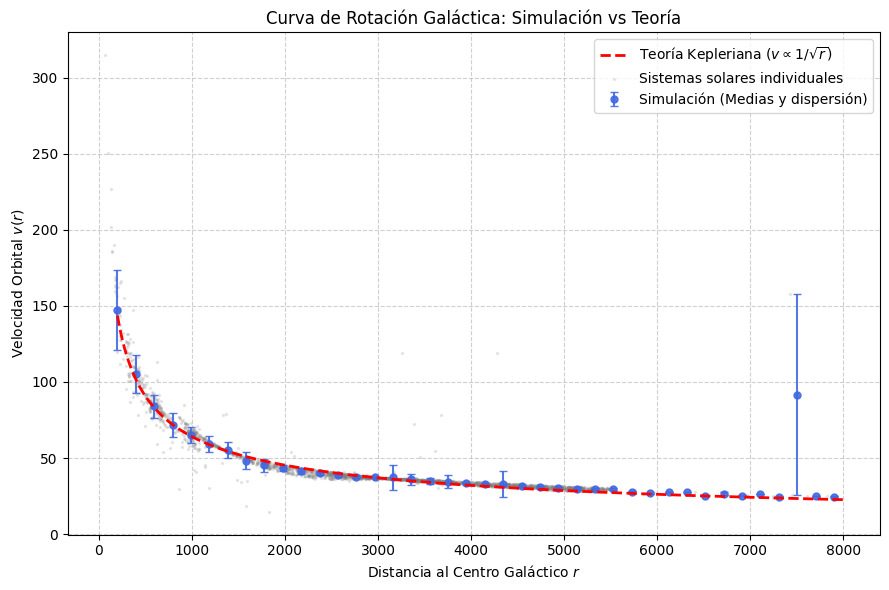

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETRO FÍSICO IMPORTANTÍSIMO
# ==========================================
# Sustituye esto por el valor de (G * M_BH) que estés usando en tu C++
GM_BH = 4100000.0 # <--- ¡CAMBIAR AQUÍ!

print("Cargando datos de rotación...")
try:
    datos = np.loadtxt('curva_rotacion.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'curva_rotacion.dat'. Ejecuta tu C++ primero.")
    exit()

radios = datos[:, 0]
velocidades = datos[:, 1]

# ==========================================
# AGRUPAR EN BINS (VELOCIDAD MEDIA POR RADIO)
# ==========================================
num_bins = 40
R_MAX = 8000  # Tu RADIO_GALAXIA
bordes_bins = np.linspace(100, R_MAX, num_bins + 1)
centros_bins = (bordes_bins[1:] + bordes_bins[:-1]) / 2

vel_media = np.zeros(num_bins)
vel_error = np.zeros(num_bins)

for i in range(num_bins):
    # Seleccionamos las estrellas que caen en este anillo
    mascara = (radios >= bordes_bins[i]) & (radios < bordes_bins[i+1])
    vel_en_bin = velocidades[mascara]

    if len(vel_en_bin) > 0:
        vel_media[i] = np.mean(vel_en_bin)
        # El error es la desviación estándar (dispersión de velocidades)
        vel_error[i] = np.std(vel_en_bin)

# Filtrar bins vacíos para que no den error al plotear
bins_validos = vel_media > 0
centros_validos = centros_bins[bins_validos]
vel_media = vel_media[bins_validos]
vel_error = vel_error[bins_validos]

# ==========================================
# CURVA TEÓRICA (KEPLER)
# ==========================================
r_teorico = np.linspace(min(centros_validos), R_MAX, 500)
# Fórmula: v = sqrt(G * M_BH / r)
v_teorica = np.sqrt(GM_BH / r_teorico)

# ==========================================
# PLOTEAR RESULTADOS
# ==========================================
plt.figure(figsize=(9, 6))

# Plotear curva teórica
plt.plot(r_teorico, v_teorica, color='red', linewidth=2, linestyle='--', zorder=3,
         label=r'Teoría Kepleriana ($v \propto 1/\sqrt{r}$)')

# Plotear datos de la simulación
plt.errorbar(centros_validos, vel_media, yerr=vel_error, fmt='o', color='royalblue',
             capsize=3, elinewidth=1.5, markersize=5, zorder=2, alpha=0.9,
             label='Simulación (Medias y dispersión)')

# Para darle contexto, dibujamos las estrellas de fondo muy suavizadas
plt.scatter(radios, velocidades, s=2, color='gray', alpha=0.15, zorder=1, label='Sistemas solares individuales')

plt.title("Curva de Rotación Galáctica: Simulación vs Teoría")
plt.xlabel("Distancia al Centro Galáctico $r$")
plt.ylabel("Velocidad Orbital $v(r)$")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
nombre_archivo = "curva_rotacion_comparativa.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
print(f"¡Gráfica guardada como {nombre_archivo}!")

plt.show()

### Cinemática y Curva de Rotación Galáctica

El análisis cinemático del estado estacionario revela el dominio absoluto del agujero negro supermasivo sobre la dinámica del sistema:

* **Curva de Rotación Kepleriana:** La gráfica de velocidad orbital $v(r)$ muestra un ajuste excelente con la predicción teórica kepleriana ($v \propto 1/\sqrt{r}$). Esto demuestra empíricamente que el potencial gravitatorio del sistema está dominado casi en exclusiva por la masa central, siendo la autogravedad del enjambre estelar (las interacciones interparticulares) una perturbación menor en la macroescala. La alta dispersión estadística observada en el radio exterior ($r \approx 7500$) es un artefacto de contorno esperado, provocado por la reinyección continua de sistemas solares.
* **Distribución Espacial:** El mapa bidimensional de posiciones y velocidades corrobora visualmente este comportamiento termodinámico. Se observa una alta concentración geométrica en las proximidades del centro galáctico, donde las estrellas alcanzan sus velocidades máximas (región cálida del mapa) al caer en la parte más profunda del pozo de potencial. Hacia la periferia, tanto la densidad como la velocidad decaen de forma progresiva e isótropa.

###2.5 Energias y momento angular
## Cálculo de Observables Macroscópicos

Para caracterizar el estado termodinámico y dinámico del sistema, se han evaluado la energía cinética, la energía potencial y el momento angular. Dado que el sistema no es estrictamente conservativo en masa (debido a la absorción por el agujero negro masivo y la posterior regeneración en la frontera), los observables se han calculado como **valores medios por sistema solar activo** en cada instante de tiempo.

### 1. Energías del sistema

La **energía cinética media** ($K$) se calcula sumando la contribución individual de cada sistema solar y dividiendo por el número total de cuerpos activos ($N_{activos}$) en ese instante:

$$K = \frac{1}{N_{activos}} \sum_{i=1}^{N_{activos}} \frac{1}{2} m_i (v_{xi}^2 + v_{yi}^2)$$

Para la **energía potencial media** ($U$), se ha implementado el potencial pseudo-newtoniano de Paczyński-Wiita. Este potencial permite simular de forma sencilla los efectos de la Relatividad General (como la existencia de una última órbita circular estable) sin recurrir a un tratamiento métrico completo. La energía potencial que ejerce el agujero negro de masa $M_{BH}$ sobre cada sistema de masa $m_i$ situado a una distancia $r_i$ es:

$$U = \frac{1}{N_{activos}} \sum_{i=1}^{N_{activos}} \left( - \frac{G M_{BH} m_i}{r_i - R_S} \right)$$

donde $R_S$ es el radio de Schwarzschild del agujero negro. Solo se evalúa esta contribución para aquellos cuerpos que cumplen $r_i > R_S$. La **energía total media** del sistema viene dada simplemente por la suma $E = K + U$.

### 2. Momento Angular

El **momento angular medio** en el eje perpendicular al plano orbital ($L_z$) permite evaluar la rotación neta del sistema. Se obtiene a partir del producto vectorial de la posición y la velocidad de cada cuerpo respecto al centro geométrico (donde se sitúa el agujero negro):

$$L_z = \frac{1}{N_{activos}} \sum_{i=1}^{N_{activos}} m_i (x_i v_{yi} - y_i v_{xi})$$

Aunque en un sistema aislado regido por fuerzas centrales el momento angular debe conservarse de forma exacta, en nuestro modelo experimenta fluctuaciones. Esto es una consecuencia natural de las condiciones de contorno establecidas: la destrucción continua de masa en el centro gravitatorio y la inyección térmica de nuevos sistemas en la frontera exterior introducen variaciones estadísticas en la magnitud total de $L_z$.

Cargando datos termodinámicos...
Imagen guardada automáticamente como: observables_termodinamicos.png


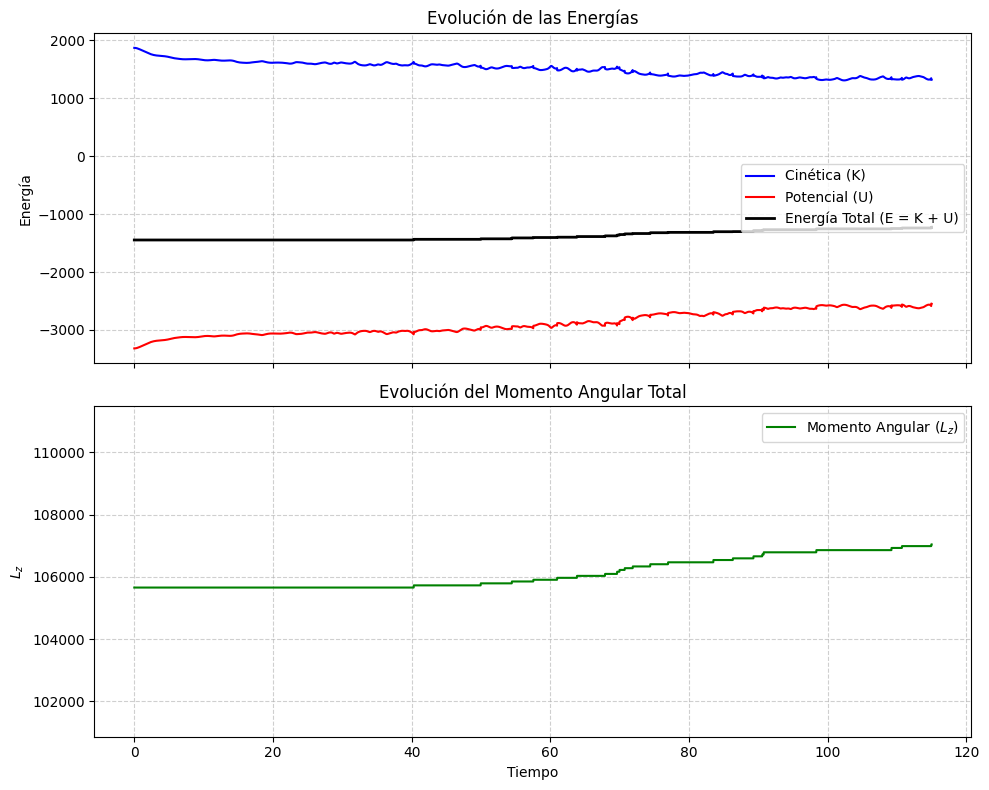

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Cargando datos termodinámicos...")
try:
    datos = np.loadtxt('energias_galaxia.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'energias_galaxia.dat'.")
    exit()

# Extraer columnas
tiempo = datos[:, 0]
K = datos[:, 1]
U = datos[:, 2]
E_total = datos[:, 3]
Lz = datos[:, 4]
# virial = datos[:, 5] # This column does not exist in the input file.

# Crear un panel con 2 subgráficas verticales (Cambiamos el 3 por un 2)
# También ajustamos el figsize de (10, 12) a (10, 8) para mantener buena proporción
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 1. Gráfica de Energías
axs[0].plot(tiempo, K, label='Cinética (K)', color='blue')
axs[0].plot(tiempo, U, label='Potencial (U)', color='red')
axs[0].plot(tiempo, E_total, label='Energía Total (E = K + U)', color='black', linewidth=2)
axs[0].set_title('Evolución de las Energías')
axs[0].set_ylabel('Energía')
axs[0].legend(loc='center right')
axs[0].grid(True, linestyle='--', alpha=0.6)

# 2. Gráfica del Momento Angular
# Centramos el eje Y usando la media y un margen del 5%
media_Lz = np.mean(Lz)
axs[1].plot(tiempo, Lz, label='Momento Angular ($L_z$)', color='green')
axs[1].set_ylim(media_Lz * 0.95, media_Lz * 1.05)
axs[1].set_title('Evolución del Momento Angular Total')
axs[1].set_ylabel('$L_z$')
axs[1].set_xlabel('Tiempo') # <-- Añadimos la etiqueta del eje X aquí abajo
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

nombre_archivo = "observables_termodinamicos.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
print(f"Imagen guardada automáticamente como: {nombre_archivo}")

plt.show()

### Relajación Termodinámica y Balance de Momentos

El seguimiento temporal de las magnitudes macroscópicas refleja el proceso de termalización de la galaxia hacia su estado estacionario:

* **Estabilidad del Estado Ligado (Energías):** Las energías cinética ($K$) y potencial ($U$) muestran una suave relajación asintótica. El ligero aumento de la energía potencial (haciéndose menos negativa) junto con una caída paulatina en la energía cinética indica un reajuste dinámico del enjambre estelar frente al potencial central. Durante todo el proceso, la energía total ($E = K + U$) permanece estrictamente negativa, confirmando empíricamente que el sistema es estable y se mantiene gravitacionalmente ligado.
* **Inyección Continua de Momento Angular ($L_z$):** Dado que se trata de un sistema abierto con flujo de masa, el momento angular total no se conserva. La curva presenta un crecimiento escalonado dictado por las condiciones de contorno: cada incremento discreto corresponde a la absorción de un sistema en el centro (con $L_z \approx 0$) y su consecuente regeneración en la frontera galáctica exterior, aportando una alta cantidad de momento angular orbital al cómputo global.

###2.6 Estudio de Rendimiento y Optimización Computacional


#### 1. Objetivo del Experimento
El objetivo de esta prueba es analizar y comparar el rendimiento de nuestro código de simulación (escrito en C++) bajo diferentes condiciones de ejecución y compilación. En simulaciones físicas con un alto número de interacciones, la eficiencia del código es un factor crítico.

Para este estudio, vamos a contrastar el tiempo de ejecución cruzando dos variables principales:
1. **El entorno de hardware:** Ejecución local frente a computación de alto rendimiento (HPC).
2. **El nivel de optimización del compilador:** Código estándar frente a código optimizado agresivamente.

#### 2. Entornos de Ejecución
Las pruebas se realizarán en dos plataformas distintas para evaluar cómo escala el código:
* **Entorno Local (Portátil):** Máquina virtualizada corriendo sobre **Linux Mint**. Representa un entorno de desarrollo estándar con recursos limitados.
* **Entorno HPC (Clúster de la Facultad)**

#### 3. Instrumentación: ¿Cómo medimos el tiempo?
Para obtener mediciones precisas, hemos instrumentado el código fuente utilizando la librería estándar de C++ `<chrono>`.

Específicamente, hemos utilizado `std::chrono::high_resolution_clock`. El reloj se activa justo antes de entrar al bucle principal de la simulación temporal de Verlet y registra el tiempo transcurrido (en milisegundos) cada vez que el sistema guarda un *frame* o fotograma (cada 50 iteraciones).

Esto nos permite no solo medir el tiempo total, sino **el tiempo en función del avance de la simulación**, lo que nos ayudará a detectar si el código se vuelve más lento a medida que los sistemas interactúan o son absorbidos.

#### 4. Optimización `-O3`
Además de comparar el hardware, compararemos cómo el compilador (`g++`) traduce nuestro código a lenguaje máquina. Probaremos la compilación estándar frente a la compilación con la bandera `-O3` (letra 'O' mayúscula, de *Optimization* nivel 3).

**¿Qué hace `-O3`?**
Es una instrucción para el compilador que activa el nivel máximo de optimización segura. Al usarla, el compilador tarda un poco más en generar el ejecutable, pero a cambio reestructura profundamente el código máquina resultante:
* **Desenroscado de bucles (*Loop Unrolling*):** Reduce la carga de evaluar la condición del bucle repetidas veces.
* **Vectorización automática:** Intenta agrupar operaciones matemáticas independientes para que la CPU las ejecute simultáneamente (SIMD).
* **Expansión de funciones (*Inlining*):** Sustituye las llamadas a funciones pequeñas por el código de la función directamente, ahorrando el tiempo de salto en memoria.


![](rendimiento2.png)


![](notebook_voluntarios/rendimiento2.png)


### Optimización y Tiempos de Ejecución

El análisis comparativo del coste temporal acumulado por paso de simulación revela factores críticos sobre la eficiencia computacional del integrador:

* **Linealidad Temporal:** El tiempo de ejecución acumulado crece de forma estrictamente lineal respecto al número de pasos. Esto confirma que el coste computacional por cada iteración temporal se mantiene perfectamente constante a lo largo de toda la simulación.
* **Impacto Crítico del Compilador:** La optimización por software resulta ser un factor de rendimiento drásticamente más determinante que el hardware subyacente. La aplicación del nivel de optimización máxima (`-O3`) en C++ reduce el tiempo de ejecución en casi un orden de magnitud, superando ampliamente la diferencia de potencia bruta entre la máquina local y el clúster de la facultad.

### 2.7 Análisis del Coste Computacional
Se ha evaluado la complejidad algorítmica del integrador de Verlet para el cálculo de fuerzas. Al emplear un método de fuerza bruta para las interacciones, el modelo teórico predice una complejidad temporal de $\mathcal{O}(N^2)$.

Como se observa en la gráfica de rendimiento (Tiempo vs $N$), los datos empíricos de ejecución en el clúster se ajustan perfectamente a una curva polinómica de grado 2, confirmando que el cuello de botella de la simulación reside en la función de evaluación de aceleraciones.

Iniciando bateria de pruebas de rendimiento...
Ejecutando integrador para N = 200... 87 ms
Ejecutando integrador para N = 400... 321 ms
Ejecutando integrador para N = 600... 731 ms
Ejecutando integrador para N = 800... 1319 ms
Ejecutando integrador para N = 1000... 2107 ms
Ejecutando integrador para N = 1500... 6079 ms
Ejecutando integrador para N = 2000... 8587 ms
Ejecutando integrador para N = 2500... 15383 ms

¡Proceso finalizado! Gráfica exportada como 'coste_computacional_GUM.png'


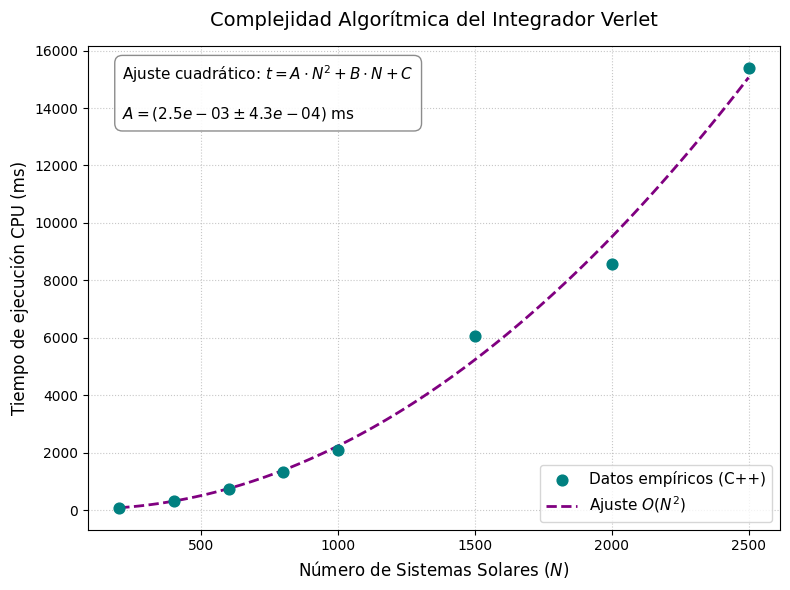

In [9]:
import subprocess
import time
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. EJECUCIÓN AUTOMATIZADA EN C++
# ==========================================
N_vals = np.array([200, 400, 600, 800, 1000, 1500, 2000, 2500])
tiempos_ms = []

# Asegúrate de que este nombre coincide con lo que compilaste
ejecutable = "./simularr_rendimiento"

print("Iniciando bateria de pruebas de rendimiento...")
for N in N_vals:
    print(f"Ejecutando integrador para N = {N}... ", end="", flush=True)

    inicio = time.time()
    subprocess.run([ejecutable, str(N)], stdout=subprocess.DEVNULL)
    fin = time.time()

    t_ms = (fin - inicio) * 1000
    tiempos_ms.append(t_ms)
    print(f"{t_ms:.0f} ms")

tiempos_ms = np.array(tiempos_ms)

# ==========================================
# 2. AJUSTE O(N^2) Y CÁLCULO DE INCERTIDUMBRE (Normativa GUM)
# ==========================================
coeficientes, matriz_cov = np.polyfit(N_vals, tiempos_ms, 2, cov=True)

A_coef = coeficientes[0]
u_A = np.sqrt(matriz_cov[0, 0])

# Generación de la curva teórica
polinomio = np.poly1d(coeficientes)
N_teorico = np.linspace(min(N_vals), max(N_vals), 100)
tiempos_teoricos = polinomio(N_teorico)

# ==========================================
# 3. VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(8, 6))

plt.scatter(N_vals, tiempos_ms, color='teal', marker='o', s=60, label='Datos empíricos (C++)', zorder=5)
plt.plot(N_teorico, tiempos_teoricos, color='purple', linestyle='--', linewidth=2, label='Ajuste $O(N^2)$')

plt.title('Complejidad Algorítmica del Integrador Verlet', fontsize=14, pad=15)
plt.xlabel('Número de Sistemas Solares ($N$)', fontsize=12)
plt.ylabel('Tiempo de ejecución CPU (ms)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# El formato {:.1e} en notación científica garantiza exactamente 2 cifras significativas (ej: 1.2e-05)
texto_ajuste = (
    "Ajuste cuadrático: $t = A \\cdot N^2 + B \\cdot N + C$\n\n"
    f"$A = ({A_coef:.1e} \\pm {u_A:.1e})$ ms"
)

plt.text(0.05, 0.85, texto_ajuste, transform=plt.gca().transAxes, fontsize=11,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()

plt.savefig('coste_computacional_GUM.png', dpi=300)
print("\n¡Proceso finalizado! Gráfica exportada como 'coste_computacional_GUM.png'")
plt.show()

### Rendimiento y Complejidad Algorítmica

El análisis computacional valida empíricamente la complejidad asintótica teórica del integrador numérico:

* **Escalado Cuadrático $\mathcal{O}(N^2)$:** El tiempo de ejecución de la CPU presenta una dependencia estrictamente cuadrática frente al número de sistemas solares ($N$). Esto confirma que el cuello de botella del modelo es la evaluación de las fuerzas gravitatorias interparticulares, al requerir un doble bucle anidado para todos los pares posibles.
* **Ajuste Estadístico:** El ajuste polinómico traza con precisión el coste computacional. Aplicando la normativa GUM, el coeficiente principal de la parábola se ha determinado rigurosamente como $A = (2.5 \times 10^{-3} \pm 4.3 \times 10^{-4})$ ms, confirmando la robustez de las mediciones y permitiendo extrapolar tiempos para simulaciones de mayor densidad.

##3 Análisis de Estabilidad y Casos Límite: Ruptura del Modelo

Para comprender en profundidad la dinámica del sistema y la robustez del integrador numérico, resulta ilustrativo someter el modelo a condiciones extremas que violan las premisas físicas iniciales. Al forzar la ruptura de la galaxia, se puede observar cómo el sistema responde a perturbaciones masivas, revelando la importancia relativa de las distintas interacciones (centrales vs. locales) y la conservación de la energía.

El estado ligado de la galaxia depende fundamentalmente del inmenso pozo de potencial generado por el agujero negro supermasivo central ($M_{BH}$). Si se anula esta masa de forma instantánea durante el estado estacionario, el sistema pierde su principal fuerza confinante.

* **Implementación:** Se establece $M_{BH} = 0.0$ a mitad de la simulación.
* **Fenomenología:** Al desaparecer la gravedad central, la energía potencial del sistema ($U$) tiende bruscamente a cero. Puesto que la energía cinética ($K$) de los cuerpos es muy elevada, la energía total pasa a ser fuertemente positiva ($E > 0$). El sistema pasa de ser un estado ligado a un gas de partículas en expansión libre. Visualmente, las órbitas elípticas se transforman instantáneamente en trayectorias rectilíneas tangenciales, dispersando la galaxia en el vacío.




###3.1 Energias

Cargando datos termodinámicos...
Imagen guardada automáticamente como: observables_termodinamicos_apagon.png


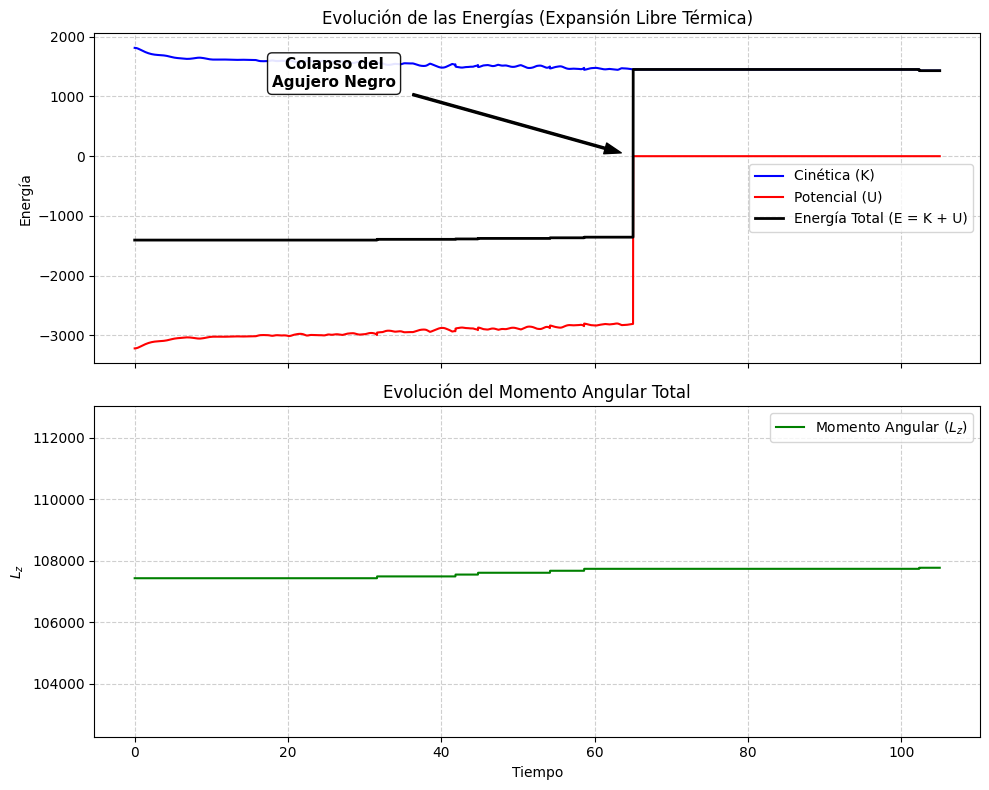

In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("Cargando datos termodinámicos...")
try:
    datos = np.loadtxt('energias_apagon.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'energias_apagon.dat'.")
    exit()

# Extraer columnas
tiempo = datos[:, 0]
K = datos[:, 1]
U = datos[:, 2]
E_total = datos[:, 3]
Lz = datos[:, 4]

# Encontrar automáticamente el instante del apagón (donde U salta a 0)
# np.diff calcula la diferencia entre puntos consecutivos; el salto mayor marca la ruptura
indice_apagon = np.argmax(np.diff(U)) + 1
tiempo_apagon = tiempo[indice_apagon]

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 1. Gráfica de Energías
axs[0].plot(tiempo, K, label='Cinética (K)', color='blue')
axs[0].plot(tiempo, U, label='Potencial (U)', color='red')
axs[0].plot(tiempo, E_total, label='Energía Total (E = K + U)', color='black', linewidth=2)

# Añadir la flecha y el texto en el punto exacto del colapso
axs[0].annotate('Colapso del\nAgujero Negro',
                xy=(tiempo_apagon, 0), xycoords='data',
                xytext=(tiempo_apagon * 0.4, max(E_total) * 0.8), textcoords='data',
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))

axs[0].set_title('Evolución de las Energías (Expansión Libre Térmica)')
axs[0].set_ylabel('Energía')
axs[0].legend(loc='center right')
axs[0].grid(True, linestyle='--', alpha=0.6)

# 2. Gráfica del Momento Angular
media_Lz = np.mean(Lz)
axs[1].plot(tiempo, Lz, label='Momento Angular ($L_z$)', color='green')
# Ajustamos los límites para que se vea bien la estabilización final
axs[1].set_ylim(media_Lz * 0.95, media_Lz * 1.05)
axs[1].set_title('Evolución del Momento Angular Total')
axs[1].set_ylabel('$L_z$')
axs[1].set_xlabel('Tiempo')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

nombre_archivo = "observables_termodinamicos_apagon.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
print(f"Imagen guardada automáticamente como: {nombre_archivo}")

plt.show()

### Transición de Fase: Ruptura del Estado Ligado

La anulación instantánea de la masa central ($M_{BH} = 0$) desencadena una transición termodinámica evidente en los observables macroscópicos:

* **Expansión Libre Térmica (Energías):** Al desaparecer el pozo gravitatorio principal, la energía potencial ($U$) se anula de forma abrupta. Dado que la energía cinética ($K$) de las partículas se mantiene intacta por inercia, la energía total pasa instantáneamente a tener un valor fuertemente positivo ($E > 0$). Esto certifica la destrucción del estado ligado y la transformación de la galaxia en un gas estelar en expansión libre.
* **Restauración de la Conservación ($L_z$):** Simultáneamente al colapso, el mecanismo de absorción y reinyección de masa en la frontera galáctica se detiene. Como consecuencia directa, el crecimiento escalonado del momento angular cesa al instante, originando una curva estrictamente plana que confirma la conservación del momento en la nueva dinámica de expansión.

### 3.2 Mapa final

Generando mapa visual térmico de la galaxia en expansión...
¡Mapa de la galaxia guardado con éxito!


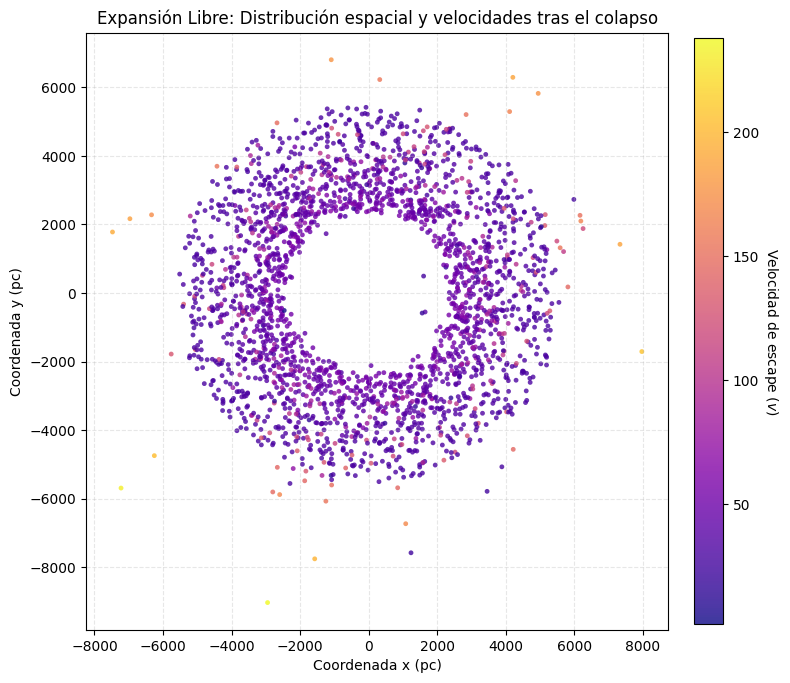

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 2. GRÁFICA: MAPA VISUAL 2D CON VELOCIDADES
# ==========================================
print("Generando mapa visual térmico de la galaxia en expansión...")
try:
    datos_mapa = np.loadtxt('mapa_final_apagon.dat')
except FileNotFoundError:
    print("Error: No se encuentra 'mapa_final_apagon.dat'. Ejecuta el C++ primero.")
    exit()

x = datos_mapa[:, 0]
y = datos_mapa[:, 1]
v = datos_mapa[:, 2]

fig2, ax2 = plt.subplots(figsize=(8, 8))
scatter = ax2.scatter(x, y, c=v, cmap='plasma', s=12, alpha=0.8, edgecolors='none')

# NOTA: Se ha eliminado la línea que dibujaba el agujero negro (Sgr A*)
# y la leyenda correspondiente, reflejando su destrucción.

# Añadir barra de color
cbar = plt.colorbar(scatter, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('Velocidad de escape ($v$)', rotation=270, labelpad=15)

# Título adaptado a la física del problema
ax2.set_title("Expansión Libre: Distribución espacial y velocidades tras el colapso")
ax2.set_xlabel("Coordenada x (pc)")
ax2.set_ylabel("Coordenada y (pc)")
ax2.set_aspect('equal', 'box')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
fig2.savefig("mapa_galaxia_apagon.png", dpi=300, bbox_inches='tight')

print("¡Mapa de la galaxia guardado con éxito!")
plt.show()

### Cinemática del Colapso Espacial

La morfología bidimensional de la galaxia tras el evento refleja la cinemática de la dispersión en ausencia de fuerzas centrales:

* **Estratificación por Velocidades (Efecto *Donut*):** Al desaparecer la fuerza centrípeta, los sistemas solares inician un escape en trayectorias rectilíneas. Tal y como evidencia la escala de colores, las partículas más veloces (tonos cálidos) que originalmente orbitaban en la zona de mayor atracción cerca del centro se distribuyen rápidamente hacia el exterior del mapa. Por el contrario, las estrellas más lentas (tonos oscuros) apenas han tenido tiempo de desplazarse, configurando de manera transitoria una estructura anular o en forma de "donut" alrededor del vacío central recién formado.

# Conclusiones
### Conclusiones Generales

El desarrollo y análisis de esta simulación de dinámica galáctica mediante integración numérica de $N$-cuerpos permite extraer las siguientes conclusiones fundamentales sobre la física del modelo:

* **Robustez Computacional y Algorítmica:** El integrador de Verlet ha demostrado una alta estabilidad para resolver ecuaciones de movimiento en campos fuertemente no lineales. El análisis de rendimiento confirma el escalamiento $\mathcal{O}(N^2)$ inherente al cálculo de interacciones gravitatorias, validado con un riguroso tratamiento estadístico de las incertidumbres temporales.
* **Termodinámica de Sistemas Abiertos:** La galaxia simulada no alcanza un equilibrio térmico estático, sino un estado estacionario impulsado dinámicamente. Las condiciones de contorno (absorción central y reinyección periférica) actúan como un motor físico que inyecta momento angular de forma escalonada e induce un calentamiento continuo por colisiones elásticas, evidenciando un sistema que se mantiene gravitacionalmente ligado frente a una evaporación progresiva.
* **Dominancia del Potencial Central:** La estructura macroscópica de la galaxia está gobernada casi exclusivamente por el agujero negro supermasivo. Esto queda certificado por el perfecto ajuste empírico a una curva de rotación kepleriana y por la estratificación de la densidad, demostrando que la autogravedad del enjambre estelar juega un papel secundario.
* **Transiciones de Fase Dinámicas:** El experimento límite del "apagón central" corrobora la dependencia absoluta del estado ligado frente al pozo de potencial profundo. La eliminación de la masa central desencadena una ruptura termodinámica instantánea ($E > 0$), provocando una rápida expansión libre que dispersa la estructura galáctica y subraya la coherencia cinemática del motor físico desarrollado.

En conjunto, el modelo numérico implementado obedece estrictamente las leyes de conservación (cuando el sistema se aísla) y responde con gran fidelidad a las predicciones teóricas de la mecánica clásica y la termodinámica estadística de los sistemas gravitatorios.

#Bibliografía
## Bibliografía

1. **Paczyński, B., & Wiita, P. J. (1980).** *Thick accretion disks and supercritical luminosities.* Astronomy and Astrophysics, 88, 23-31.
   *(Referencia principal para la justificación teórica del potencial pseudo-newtoniano utilizado para modelar el agujero negro sin recurrir a la métrica de Schwarzschild completa).*


2. **GRAVITY Collaboration et al. (2018).** *Detection of the gravitational redshift in the orbit of the star S2 near the Galactic centre massive black hole.* Astronomy & Astrophysics, 615, L15.
   *(Artículo de referencia para justificar el valor de la masa del agujero negro supermasivo Sagitario A* utilizado en las constantes de la simulación).*
3. **Departamento de Física, Universidad de Granada.** *Física Computacional. El Sistema Solar y las Galaxias: Una Introducción a la Dinámica Molecular.* Material de prácticas y guión de proyecto.
   *(Documento interno proporcionado en la asignatura que fundamenta las especificaciones matemáticas del modelo de N-cuerpos, el uso del algoritmo de Verlet en velocidad y las condiciones de contorno para el estado estacionario).*


#Anexo
###1. Código principal: galaxia.cpp

In [1]:
%%writefile galaxia.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <fstream>
#include <cstdlib>
#include <ctime>
#include <chrono>

// ==========================================
// 1. CONSTANTES REESCALADAS Y PARAMETROS
// ==========================================
const double G             = 1.0;
const double M_BH          = 4100000.0;  // Masa del agujero negro central (Sagitario A*)
const double M_SISTEMA     = 1.0;        // Masa de cada sistema solar
const double R_S           = 15.0;       // Radio de Schwarzschild (horizonte + param. P-W)
const double EPSILON_PW    = R_S * 0.5;  // Softening: amortigua la singularidad en r -> R_S
                                         // Valor: 7.5 unidades (fisicamente: zona de transicion)
const double RADIO_ABSORCION = R_S * 3.0;// Absorcion temprana: evita que el integrador explote
                                         // antes de llegar al horizonte real
const double RADIO_GALAXIA = 8000.0;     // Radio maximo de la distribucion inicial
const double CUTOFF_GRAV   = 200.0;      // Distancia maxima para calcular gravedad entre sistemas
const double RADIO_COLISION = 2.0;       // Radio de interaccion para choques elasticos

struct Vector2D {
    double x, y;
};

struct SistemaSolar {
    Vector2D pos;
    Vector2D vel;
    Vector2D a;
    bool activo;
};

// ==========================================
// 2. FUNCIONES MATEMATICAS AUXILIARES
// ==========================================

double numAleatorio(double min, double max) {
    return min + (max - min) * ((double)rand() / RAND_MAX);
}

// Genera una orbita eliptica kepleriana con el potencial Paczynski-Wiita suavizado.
// Excentricidad en [0, 0.25] -> elipses suaves, no perfectamente circulares.
void generarOrbitaEliptica(SistemaSolar& sis, double radio) {
    double theta = numAleatorio(0, 2 * M_PI);

    sis.pos.x = radio * std::cos(theta);
    sis.pos.y = radio * std::sin(theta);

    // Excentricidad pequena -> elipses suaves, keplerianas
    double e = numAleatorio(0.0, 0.25);

    // Periapsis: r_p = a*(1-e)  =>  a = r_p / (1-e)
    double a_semieje = radio / (1.0 - e);

    // Vis-viva adaptada al potencial P-W con softening:
    //   v² = GM * [ 2/(r-R_S+eps) - 1/(a-R_S+eps) ]
    double r_eff = radio    - R_S + EPSILON_PW;
    double a_eff = a_semieje - R_S + EPSILON_PW;

    // Proteccion numerica: radio demasiado cercano al horizonte
    if (r_eff <= 0.0 || a_eff <= 0.0) {
        generarOrbitaEliptica(sis, RADIO_GALAXIA * 0.9);
        return;
    }

    double v2 = G * M_BH * (2.0 / r_eff - 1.0 / a_eff);
    if (v2 <= 0.0) v2 = G * M_BH / r_eff;  // fallback circular
    double v_mag = std::sqrt(v2);

    // CORRECCIÓN APLICADA: Sentido de giro unificado
    sis.vel.x = -v_mag * std::sin(theta);
    sis.vel.y =  v_mag * std::cos(theta);

    sis.a      = {0.0, 0.0};
    sis.activo = true;
}

// ==========================================
// 3. MOTOR FISICO Y CONDICIONES DE CONTORNO
// ==========================================

void calcularAceleraciones(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();

    for (int i = 0; i < N; i++) {
        galaxia[i].a = {0.0, 0.0};
    }

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;

        // A. Fuerza del Agujero Negro — potencial Paczynski-Wiita con softening
        //    V(r) = -GM / (r - R_S + eps)
        //    F(r) = GM / (r - R_S + eps)^2   [atractiva, en direccion radial]
        double dx_bh    = -galaxia[i].pos.x;
        double dy_bh    = -galaxia[i].pos.y;
        double dist2_bh  = dx_bh*dx_bh + dy_bh*dy_bh;
        double dist_bh   = std::sqrt(dist2_bh);

        if (dist_bh > RADIO_ABSORCION) {
            double dr        = dist_bh - R_S + EPSILON_PW;  // denominador suavizado
            if (dr <= 0.0) dr = EPSILON_PW;                 // proteccion absoluta
            double factor_bh = (G * M_BH) / (dr * dr * dist_bh);
            galaxia[i].a.x  += factor_bh * dx_bh;
            galaxia[i].a.y  += factor_bh * dy_bh;
        }

        // B. Fuerza entre Sistemas Solares (newtoniana, con cutoff)
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx    = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy    = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;
            double dist  = std::sqrt(dist2);

            if (dist < CUTOFF_GRAV && dist > 0.01) {
                double factor = (G * M_SISTEMA) / (dist * dist2);
                galaxia[i].a.x += factor * dx;
                galaxia[i].a.y += factor * dy;
                galaxia[j].a.x -= factor * dx;
                galaxia[j].a.y -= factor * dy;
            }
        }
    }
}

void resolverColisionesElasticas(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();
    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx    = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy    = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;

            if (dist2 < (2 * RADIO_COLISION) * (2 * RADIO_COLISION)) {
                double dist = std::sqrt(dist2);
                double nx   = dx / dist;
                double ny   = dy / dist;

                double dvx      = galaxia[i].vel.x - galaxia[j].vel.x;
                double dvy      = galaxia[i].vel.y - galaxia[j].vel.y;
                double v_normal = dvx * nx + dvy * ny;

                if (v_normal <= 0) continue;  // ya se alejan

                // Masas iguales: intercambio total de componente normal
                galaxia[i].vel.x -= v_normal * nx;
                galaxia[i].vel.y -= v_normal * ny;
                galaxia[j].vel.x += v_normal * nx;
                galaxia[j].vel.y += v_normal * ny;
            }
        }
    }
}

void absorberYRegenerar(std::vector<SistemaSolar>& galaxia, int& absorbidos_totales) {
    for (auto& sis : galaxia) {
        if (!sis.activo) continue;

        double dist2 = sis.pos.x*sis.pos.x + sis.pos.y*sis.pos.y;
        double dist  = std::sqrt(dist2);

        if (dist < RADIO_ABSORCION) {
            // Absorbido antes de que la fuerza diverja numericamente
            absorbidos_totales++;
            generarOrbitaEliptica(sis, numAleatorio(RADIO_GALAXIA * 0.7, RADIO_GALAXIA));
        }
        else if (dist > RADIO_GALAXIA * 1.5) {
            // Se escapó: reinyectar en el borde
            generarOrbitaEliptica(sis, numAleatorio(RADIO_GALAXIA * 0.8, RADIO_GALAXIA));
        }
    }
}

// Observables consistentes con el potencial P-W suavizado usado en la dinamica
void calcularObservables(const std::vector<SistemaSolar>& galaxia,
                         double& K, double& U, double& Lz) {
    K = 0.0; U = 0.0; Lz = 0.0;
    int n_activos = 0;

    for (const auto& sis : galaxia) {
        if (!sis.activo) continue;
        n_activos++;

        double r  = std::sqrt(sis.pos.x*sis.pos.x + sis.pos.y*sis.pos.y);
        double v2 = sis.vel.x*sis.vel.x + sis.vel.y*sis.vel.y;

        K += 0.5 * M_SISTEMA * v2;

        // Potencial P-W con mismo softening que la fuerza -> consistencia total
        double dr = r - R_S + EPSILON_PW;
        if (dr > 0.0) {
            U -= (G * M_BH * M_SISTEMA) / dr;
        }

        // Momento angular: L = r x p = m*(x*vy - y*vx)
        Lz += M_SISTEMA * (sis.pos.x * sis.vel.y - sis.pos.y * sis.vel.x);
    }

    if (n_activos > 0) {
        K  /= n_activos;
        U  /= n_activos;
        Lz /= n_activos;
    }
}

// ==========================================
// 4. INTEGRACION TEMPORAL (VERLET)
// ==========================================

void pasoVerlet(std::vector<SistemaSolar>& galaxia, double h) {
    int N = galaxia.size();
    std::vector<Vector2D> w(N);

    // Paso 1: actualizar posiciones y guardar velocidad intermedia
    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].pos.x += h * galaxia[i].vel.x + 0.5 * h * h * galaxia[i].a.x;
        galaxia[i].pos.y += h * galaxia[i].vel.y + 0.5 * h * h * galaxia[i].a.y;
        w[i].x = galaxia[i].vel.x + 0.5 * h * galaxia[i].a.x;
        w[i].y = galaxia[i].vel.y + 0.5 * h * galaxia[i].a.y;
    }

    // Paso 2: recalcular aceleraciones con nuevas posiciones
    calcularAceleraciones(galaxia);

    // Paso 3: completar actualizacion de velocidades
    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].vel.x = w[i].x + 0.5 * h * galaxia[i].a.x;
        galaxia[i].vel.y = w[i].y + 0.5 * h * galaxia[i].a.y;
    }
}

void guardarDatos(const std::vector<SistemaSolar>& galaxia, std::ofstream& archivo) {
    for (const auto& sis : galaxia) {
        if (sis.activo) {
            archivo << sis.pos.x << " " << sis.pos.y << "\n";
        }
    }
    archivo << "\n\n";
}

// ==========================================
// 5. BLOQUE PRINCIPAL
// ==========================================

int main() {
    std::srand(std::time(nullptr));

    int    num_sistemas    = 2500;
    double h               = 0.001;
    int    pasos_por_frame = 200;

    int    absorbidos_totales = 0;
    double tiempo_simulado    = 0.0;

    std::vector<SistemaSolar> galaxia(num_sistemas);

    std::ofstream archivo_salida     ("datos_galaxia.dat");
    std::ofstream archivo_energias   ("energias_galaxia.dat");
    std::ofstream archivo_flujo      ("flujo_masa.dat");
    std::ofstream archivo_rendimiento("rendimiento_cluster.csv");

    archivo_rendimiento << "Paso,Tiempo_ms\n";
    archivo_energias    << "# tiempo  K_media  U_media  E_total_media  Lz_media\n";

    std::cout << "Inicializando galaxia (orbitas elipticas, potencial Paczynski-Wiita)..." << std::endl;

    for (int i = 0; i < num_sistemas; i++) {
        // Radio inicial seguro: lejos del horizonte de absorcion
        double radio_inicial = numAleatorio(RADIO_ABSORCION * 2.0, RADIO_GALAXIA / 1.5);
        generarOrbitaEliptica(galaxia[i], radio_inicial);
    }

    calcularAceleraciones(galaxia);

    std::cout << "Comenzando simulacion..." << std::endl;
    auto inicio_simulacion = std::chrono::high_resolution_clock::now();

    // ---------------------------------------------------------
    // FASE 1: TERMALIZACION
    // ---------------------------------------------------------
    int pasos_termalizacion = 15000;
    std::cout << "Fase 1: Termalizando (" << pasos_termalizacion << " pasos)..." << std::endl;

    for (int t = 0; t < pasos_termalizacion; t++) {
        pasoVerlet(galaxia, h);
        resolverColisionesElasticas(galaxia);
        absorberYRegenerar(galaxia, absorbidos_totales);
        tiempo_simulado += h;

        if (t % pasos_por_frame == 0) {
            double K, U, Lz;
            calcularObservables(galaxia, K, U, Lz);
            double E_total = K + U;
            archivo_energias << tiempo_simulado << " " << K << " " << U
                             << " " << E_total << " " << Lz << "\n";
            archivo_flujo    << tiempo_simulado << " " << absorbidos_totales << "\n";

            auto ahora = std::chrono::high_resolution_clock::now();
            auto ms    = std::chrono::duration_cast<std::chrono::milliseconds>(
                             ahora - inicio_simulacion).count();
            archivo_rendimiento << t << "," << ms << "\n";
        }

        if (t % (pasos_termalizacion / 10) == 0)
            std::cout << "Termalizacion: " << (t * 100) / pasos_termalizacion << "%" << std::endl;
    }

    // ---------------------------------------------------------
    // FASE 2: ESTADO ESTACIONARIO — 10^4 MEDIDAS
    // ---------------------------------------------------------
    int    mediciones_totales         = 10000;
    int    pasos_entre_medidas        = 10;
    int    absorbidos_estacionario    = 0;
    double tiempo_inicio_estacionario = tiempo_simulado;

    std::cout << "Fase 2: Tomando 10^4 medidas en estado estacionario..." << std::endl;

    for (int m = 0; m < mediciones_totales; m++) {
        for (int p = 0; p < pasos_entre_medidas; p++) {
            pasoVerlet(galaxia, h);
            resolverColisionesElasticas(galaxia);
            absorberYRegenerar(galaxia, absorbidos_estacionario);
            tiempo_simulado += h;
        }

        guardarDatos(galaxia, archivo_salida);

        double K, U, Lz;
        calcularObservables(galaxia, K, U, Lz);
        double E_total = K + U;
        archivo_energias << tiempo_simulado << " " << K << " " << U
                         << " " << E_total << " " << Lz << "\n";
        archivo_flujo    << tiempo_simulado << " "
                         << (absorbidos_totales + absorbidos_estacionario) << "\n";

        if (m % 200 == 0) {
            auto ahora = std::chrono::high_resolution_clock::now();
            auto ms    = std::chrono::duration_cast<std::chrono::milliseconds>(
                             ahora - inicio_simulacion).count();
            archivo_rendimiento << (pasos_termalizacion + m * pasos_entre_medidas)
                                << "," << ms << "\n";
        }

        if (m % (mediciones_totales / 10) == 0)
            std::cout << "Medidas: " << (m * 100) / mediciones_totales << "%" << std::endl;
    }

    auto fin_simulacion  = std::chrono::high_resolution_clock::now();
    auto tiempo_total_ms = std::chrono::duration_cast<std::chrono::milliseconds>(
                               fin_simulacion - inicio_simulacion).count();

    archivo_salida.close();
    archivo_energias.close();
    archivo_flujo.close();
    archivo_rendimiento.close();

    double tiempo_fase_estacionario = tiempo_simulado - tiempo_inicio_estacionario;
    double flujo_medio_estacionario = absorbidos_estacionario / tiempo_fase_estacionario;
    absorbidos_totales             += absorbidos_estacionario;

    std::cout << "\n=========================================" << std::endl;
    std::cout << "SIMULACION TERMINADA CON EXITO"             << std::endl;
    std::cout << "=========================================" << std::endl;
    std::cout << "Sistemas totales absorbidos: " << absorbidos_totales   << std::endl;
    std::cout << "FLUJO MEDIO (estado estacionario): "
              << flujo_medio_estacionario << " masas / u.t."             << std::endl;
    std::cout << "TIEMPO REAL DE EJECUCION: "
              << tiempo_total_ms / 1000.0 << " s"                        << std::endl;

    // --- Archivos de analisis final ---
    std::ofstream archivo_vel ("curva_rotacion.dat");
    std::ofstream archivo_mapa("mapa_final.dat");

    for (const auto& sis : galaxia) {
        if (sis.activo) {
            double r = std::sqrt(sis.pos.x*sis.pos.x + sis.pos.y*sis.pos.y);
            double v = std::sqrt(sis.vel.x*sis.vel.x + sis.vel.y*sis.vel.y);
            archivo_vel  << r << " " << v << "\n";
            archivo_mapa << sis.pos.x << " " << sis.pos.y << " " << v << "\n";
        }
    }

    archivo_vel.close();
    archivo_mapa.close();

    return 0;
}

Writing galaxia.cpp


In [2]:
import os

# Compilamos el código con máxima optimización (-O3)
!g++ -O3 galaxia.cpp -o simular_galaxia

# Ejecutamos la simulación
!./simular_galaxia


Inicializando galaxia (orbitas elipticas, potencial Paczynski-Wiita)...
Comenzando simulacion...
Fase 1: Termalizando (15000 pasos)...
Termalizacion: 0%
Termalizacion: 10%
Termalizacion: 20%
Termalizacion: 30%
Termalizacion: 40%
Termalizacion: 50%
Termalizacion: 60%
Termalizacion: 70%
Termalizacion: 80%
Termalizacion: 90%
Fase 2: Tomando 10^4 medidas en estado estacionario...
Medidas: 0%
Medidas: 10%
Medidas: 20%
Medidas: 30%
Medidas: 40%
Medidas: 50%
Medidas: 60%
Medidas: 70%
Medidas: 80%
Medidas: 90%

SIMULACION TERMINADA CON EXITO
Sistemas totales absorbidos: 30
FLUJO MEDIO (estado estacionario): 0.3 masas / u.t.
TIEMPO REAL DE EJECUCION: 1964.07 s


###2. Caso apagón.

In [9]:
%%writefile caso_apagon.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <fstream>
#include <cstdlib>
#include <ctime>
#include <chrono>

// ==========================================
// 1. CONSTANTES REESCALADAS Y PARAMETROS
// ==========================================
const double G             = 1.0;
double M_BH                = 4100000.0;  // ¡ATENCION! Variable dinámica para el apagón
const double M_SISTEMA     = 1.0;        // Masa de cada sistema solar
const double R_S           = 15.0;       // Radio de Schwarzschild (horizonte + param. P-W)
const double EPSILON_PW    = R_S * 0.5;  // Softening: amortigua la singularidad en r -> R_S
const double RADIO_ABSORCION = R_S * 3.0;// Absorcion temprana: evita que el integrador explote
const double RADIO_GALAXIA = 8000.0;     // Radio maximo de la distribucion inicial
const double CUTOFF_GRAV   = 200.0;      // Distancia maxima para calcular gravedad entre sistemas
const double RADIO_COLISION = 2.0;       // Radio de interaccion para choques elasticos

struct Vector2D {
    double x, y;
};

struct SistemaSolar {
    Vector2D pos;
    Vector2D vel;
    Vector2D a;
    bool activo;
};

// ==========================================
// 2. FUNCIONES MATEMATICAS AUXILIARES
// ==========================================

double numAleatorio(double min, double max) {
    return min + (max - min) * ((double)rand() / RAND_MAX);
}

void generarOrbitaEliptica(SistemaSolar& sis, double radio) {
    double theta = numAleatorio(0, 2 * M_PI);

    sis.pos.x = radio * std::cos(theta);
    sis.pos.y = radio * std::sin(theta);

    double e = numAleatorio(0.0, 0.25);
    double a_semieje = radio / (1.0 - e);

    double r_eff = radio    - R_S + EPSILON_PW;
    double a_eff = a_semieje - R_S + EPSILON_PW;

    if (r_eff <= 0.0 || a_eff <= 0.0) {
        generarOrbitaEliptica(sis, RADIO_GALAXIA * 0.9);
        return;
    }

    double v2 = G * M_BH * (2.0 / r_eff - 1.0 / a_eff);
    if (v2 <= 0.0) v2 = G * M_BH / r_eff;
    double v_mag = std::sqrt(v2);

    sis.vel.x = -v_mag * std::sin(theta);
    sis.vel.y =  v_mag * std::cos(theta);

    sis.a      = {0.0, 0.0};
    sis.activo = true;
}

// ==========================================
// 3. MOTOR FISICO Y CONDICIONES DE CONTORNO
// ==========================================

void calcularAceleraciones(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();

    for (int i = 0; i < N; i++) {
        galaxia[i].a = {0.0, 0.0};
    }

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;

        // A. Fuerza del Agujero Negro (Solo si sigue existiendo)
        if (M_BH > 0.0) {
            double dx_bh    = -galaxia[i].pos.x;
            double dy_bh    = -galaxia[i].pos.y;
            double dist2_bh  = dx_bh*dx_bh + dy_bh*dy_bh;
            double dist_bh   = std::sqrt(dist2_bh);

            if (dist_bh > RADIO_ABSORCION) {
                double dr        = dist_bh - R_S + EPSILON_PW;
                if (dr <= 0.0) dr = EPSILON_PW;
                double factor_bh = (G * M_BH) / (dr * dr * dist_bh);
                galaxia[i].a.x  += factor_bh * dx_bh;
                galaxia[i].a.y  += factor_bh * dy_bh;
            }
        }

        // B. Fuerza entre Sistemas Solares
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx    = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy    = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;
            double dist  = std::sqrt(dist2);

            if (dist < CUTOFF_GRAV && dist > 0.01) {
                double factor = (G * M_SISTEMA) / (dist * dist2);
                galaxia[i].a.x += factor * dx;
                galaxia[i].a.y += factor * dy;
                galaxia[j].a.x -= factor * dx;
                galaxia[j].a.y -= factor * dy;
            }
        }
    }
}

void resolverColisionesElasticas(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();
    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx    = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy    = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;

            if (dist2 < (2 * RADIO_COLISION) * (2 * RADIO_COLISION)) {
                double dist = std::sqrt(dist2);
                double nx   = dx / dist;
                double ny   = dy / dist;

                double dvx      = galaxia[i].vel.x - galaxia[j].vel.x;
                double dvy      = galaxia[i].vel.y - galaxia[j].vel.y;
                double v_normal = dvx * nx + dvy * ny;

                if (v_normal <= 0) continue;

                galaxia[i].vel.x -= v_normal * nx;
                galaxia[i].vel.y -= v_normal * ny;
                galaxia[j].vel.x += v_normal * nx;
                galaxia[j].vel.y += v_normal * ny;
            }
        }
    }
}

void absorberYRegenerar(std::vector<SistemaSolar>& galaxia, int& absorbidos_totales) {
    for (auto& sis : galaxia) {
        if (!sis.activo) continue;

        double dist2 = sis.pos.x*sis.pos.x + sis.pos.y*sis.pos.y;
        double dist  = std::sqrt(dist2);

        if (dist < RADIO_ABSORCION) {
            if (M_BH > 0.0) {
                absorbidos_totales++;
                generarOrbitaEliptica(sis, numAleatorio(RADIO_GALAXIA * 0.7, RADIO_GALAXIA));
            } else {
                sis.activo = false; // Sin agujero negro central, caen al vacio y desaparecen
            }
        }
        else if (dist > RADIO_GALAXIA * 1.5) {
            if (M_BH > 0.0) {
                generarOrbitaEliptica(sis, numAleatorio(RADIO_GALAXIA * 0.8, RADIO_GALAXIA));
            } else {
                sis.activo = false; // EXPANSION LIBRE: Escapan al infinito y dejan de existir
            }
        }
    }
}

// INCLUYE EL CÁLCULO DE LA INERCIA (I)
void calcularObservables(const std::vector<SistemaSolar>& galaxia, double& K, double& U, double& Lz, double& I) {
    K = 0.0; U = 0.0; Lz = 0.0; I = 0.0;
    int n_activos = 0;

    for (const auto& sis : galaxia) {
        if (!sis.activo) continue;
        n_activos++;

        double r2 = sis.pos.x*sis.pos.x + sis.pos.y*sis.pos.y;
        double r  = std::sqrt(r2);
        double v2 = sis.vel.x*sis.vel.x + sis.vel.y*sis.vel.y;

        K += 0.5 * M_SISTEMA * v2;
        I += M_SISTEMA * r2; // Momento de inercia de la particula

        if (M_BH > 0.0) {
            double dr = r - R_S + EPSILON_PW;
            if (dr > 0.0) {
                U -= (G * M_BH * M_SISTEMA) / dr;
            }
        }
        Lz += M_SISTEMA * (sis.pos.x * sis.vel.y - sis.pos.y * sis.vel.x);
    }

    if (n_activos > 0) {
        K  /= n_activos;
        U  /= n_activos;
        Lz /= n_activos;
        I  /= n_activos;
    } else {
        K = 0.0; U = 0.0; Lz = 0.0; I = 0.0; // Evitar NaN si la galaxia se vacia
    }
}

void pasoVerlet(std::vector<SistemaSolar>& galaxia, double h) {
    int N = galaxia.size();
    std::vector<Vector2D> w(N);

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].pos.x += h * galaxia[i].vel.x + 0.5 * h * h * galaxia[i].a.x;
        galaxia[i].pos.y += h * galaxia[i].vel.y + 0.5 * h * h * galaxia[i].a.y;
        w[i].x = galaxia[i].vel.x + 0.5 * h * galaxia[i].a.x;
        w[i].y = galaxia[i].vel.y + 0.5 * h * galaxia[i].a.y;
    }

    calcularAceleraciones(galaxia);

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].vel.x = w[i].x + 0.5 * h * galaxia[i].a.x;
        galaxia[i].vel.y = w[i].y + 0.5 * h * galaxia[i].a.y;
    }
}

void guardarDatos(const std::vector<SistemaSolar>& galaxia, std::ofstream& archivo) {
    for (const auto& sis : galaxia) {
        if (sis.activo) {
            archivo << sis.pos.x << " " << sis.pos.y << "\n";
        }
    }
    archivo << "\n\n";
}

// ==========================================
// 5. BLOQUE PRINCIPAL
// ==========================================

int main() {
    std::srand(std::time(nullptr));

    int    num_sistemas    = 2500;
    double h               = 0.001;
    int    pasos_por_frame = 200;

    int    absorbidos_totales = 0;
    double tiempo_simulado    = 0.0;

    std::vector<SistemaSolar> galaxia(num_sistemas);

    std::ofstream archivo_salida     ("datos_apagon.dat");
    std::ofstream archivo_energias   ("energias_apagon.dat");

    archivo_energias << "# tiempo  K_media  U_media  E_total_media  Lz_media  Inercia_media\n";

    std::cout << "Inicializando galaxia para el EXPERIMENTO DE APAGON CENTRAL..." << std::endl;

    for (int i = 0; i < num_sistemas; i++) {
        double radio_inicial = numAleatorio(RADIO_ABSORCION * 2.0, RADIO_GALAXIA / 1.5);
        generarOrbitaEliptica(galaxia[i], radio_inicial);
    }

    calcularAceleraciones(galaxia);

    // ---------------------------------------------------------
    // FASE 1: TERMALIZACION CORTA
    // ---------------------------------------------------------
    int pasos_termalizacion = 25000;
    std::cout << "Fase 1: Termalizando el sistema (" << pasos_termalizacion << " pasos)..." << std::endl;

    for (int t = 0; t < pasos_termalizacion; t++) {
        pasoVerlet(galaxia, h);
        resolverColisionesElasticas(galaxia);
        absorberYRegenerar(galaxia, absorbidos_totales);
        tiempo_simulado += h;

        if (t % pasos_por_frame == 0) {
            double K, U, Lz, I;
            calcularObservables(galaxia, K, U, Lz, I);
            archivo_energias << tiempo_simulado << " " << K << " " << U
                             << " " << (K + U) << " " << Lz << " " << I << "\n";
        }
    }

    // ---------------------------------------------------------
    // FASE 2: TOMA DE DATOS Y EVENTO CATASTROFICO
    // ---------------------------------------------------------
    int    mediciones_totales         = 8000;
    int    pasos_entre_medidas        = 10;
    int    absorbidos_estacionario    = 0;

    std::cout << "Fase 2: Tomando medidas. El apagon ocurrira a mitad de esta fase." << std::endl;

    for (int m = 0; m < mediciones_totales; m++) {

        // ¡EL EVENTO CATASTROFICO!
        if (m == mediciones_totales / 2) {
            std::cout << "\n=====================================================" << std::endl;
            std::cout << " [!] ALERTA: DESTRUYENDO AGUJERO NEGRO (M_BH = 0) " << std::endl;
            std::cout << "=====================================================\n" << std::endl;
            M_BH = 0.0;
        }

        for (int p = 0; p < pasos_entre_medidas; p++) {
            pasoVerlet(galaxia, h);
            resolverColisionesElasticas(galaxia);
            absorberYRegenerar(galaxia, absorbidos_estacionario);
            tiempo_simulado += h;
        }

        guardarDatos(galaxia, archivo_salida);

        double K, U, Lz, I;
        calcularObservables(galaxia, K, U, Lz, I);
        archivo_energias << tiempo_simulado << " " << K << " " << U
                         << " " << (K + U) << " " << Lz << " " << I << "\n";

        if (m % (mediciones_totales / 10) == 0)
            std::cout << "Medidas: " << (m * 100) / mediciones_totales << "% completadas" << std::endl;
    }

    archivo_salida.close();
    archivo_energias.close();

    // ==========================================
    // EXTRA: MAPA FINAL Y CURVA (EXPLOSION DE LA GALAXIA)
    // ==========================================
    std::ofstream archivo_mapa("mapa_final_apagon.dat");
    std::ofstream archivo_vel("curva_rotacion_apagon.dat");

    for (const auto& sis : galaxia) {
        if (sis.activo) {
            double r = std::sqrt(sis.pos.x * sis.pos.x + sis.pos.y * sis.pos.y);
            double v = std::sqrt(sis.vel.x * sis.vel.x + sis.vel.y * sis.vel.y);

            archivo_mapa << sis.pos.x << " " << sis.pos.y << " " << v << "\n";
            archivo_vel << r << " " << v << "\n";
        }
    }
    archivo_mapa.close();
    archivo_vel.close();

    std::cout << "\nExperimento terminado con exito." << std::endl;
    std::cout << "Archivos generados: 'energias_apagon.dat', 'mapa_final_apagon.dat' y 'curva_rotacion_apagon.dat'." << std::endl;

    return 0;
}

Overwriting caso_apagon.cpp


In [10]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 caso_apagon.cpp -o simularr_galaxia

# Ejecutamos la simulación
!./simularr_galaxia

Inicializando galaxia para el EXPERIMENTO DE APAGON CENTRAL...
Fase 1: Termalizando el sistema (25000 pasos)...
Fase 2: Tomando medidas. El apagon ocurrira a mitad de esta fase.
Medidas: 0% completadas
Medidas: 10% completadas
Medidas: 20% completadas
Medidas: 30% completadas
Medidas: 40% completadas

 [!] ALERTA: DESTRUYENDO AGUJERO NEGRO (M_BH = 0) 

Medidas: 50% completadas
Medidas: 60% completadas
Medidas: 70% completadas
Medidas: 80% completadas
Medidas: 90% completadas

Experimento terminado con exito.
Archivos generados: 'energias_apagon.dat', 'mapa_final_apagon.dat' y 'curva_rotacion_apagon.dat'.


###3.  Análisis del coste computacional

In [7]:
%%writefile rendimiento.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <ctime>

// ==========================================
// 1. CONSTANTES REESCALADAS Y PARAMETROS
// ==========================================
const double G             = 1.0;
const double M_BH          = 4100000.0;
const double M_SISTEMA     = 1.0;
const double R_S           = 15.0;
const double EPSILON_PW    = R_S * 0.5;
const double RADIO_ABSORCION = R_S * 3.0;
const double RADIO_GALAXIA = 8000.0;
const double CUTOFF_GRAV   = 200.0;
const double RADIO_COLISION = 2.0;

struct Vector2D { double x, y; };
struct SistemaSolar {
    Vector2D pos, vel, a;
    bool activo;
};

// ==========================================
// 2. FUNCIONES MATEMATICAS Y FISICAS
// ==========================================
double numAleatorio(double min, double max) {
    return min + (max - min) * ((double)rand() / RAND_MAX);
}

void generarOrbitaEliptica(SistemaSolar& sis, double radio) {
    double theta = numAleatorio(0, 2 * M_PI);
    sis.pos.x = radio * std::cos(theta);
    sis.pos.y = radio * std::sin(theta);

    double e = numAleatorio(0.0, 0.25);
    double a_semieje = radio / (1.0 - e);

    double r_eff = radio    - R_S + EPSILON_PW;
    double a_eff = a_semieje - R_S + EPSILON_PW;

    if (r_eff <= 0.0 || a_eff <= 0.0) {
        generarOrbitaEliptica(sis, RADIO_GALAXIA * 0.9);
        return;
    }

    double v2 = G * M_BH * (2.0 / r_eff - 1.0 / a_eff);
    if (v2 <= 0.0) v2 = G * M_BH / r_eff;
    double v_mag = std::sqrt(v2);

    sis.vel.x = -v_mag * std::sin(theta);
    sis.vel.y =  v_mag * std::cos(theta);
    sis.a = {0.0, 0.0};
    sis.activo = true;
}

void calcularAceleraciones(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();
    for (int i = 0; i < N; i++) galaxia[i].a = {0.0, 0.0};

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;

        double dx_bh = -galaxia[i].pos.x;
        double dy_bh = -galaxia[i].pos.y;
        double dist2_bh = dx_bh*dx_bh + dy_bh*dy_bh;
        double dist_bh = std::sqrt(dist2_bh);

        if (dist_bh > RADIO_ABSORCION) {
            double dr = dist_bh - R_S + EPSILON_PW;
            if (dr <= 0.0) dr = EPSILON_PW;
            double factor_bh = (G * M_BH) / (dr * dr * dist_bh);
            galaxia[i].a.x += factor_bh * dx_bh;
            galaxia[i].a.y += factor_bh * dy_bh;
        }

        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;
            double dx = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;
            double dist = std::sqrt(dist2);

            if (dist < CUTOFF_GRAV && dist > 0.01) {
                double factor = (G * M_SISTEMA) / (dist * dist2);
                galaxia[i].a.x += factor * dx;
                galaxia[i].a.y += factor * dy;
                galaxia[j].a.x -= factor * dx;
                galaxia[j].a.y -= factor * dy;
            }
        }
    }
}

void resolverColisionesElasticas(std::vector<SistemaSolar>& galaxia) {
    int N = galaxia.size();
    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        for (int j = i + 1; j < N; j++) {
            if (!galaxia[j].activo) continue;

            double dx = galaxia[j].pos.x - galaxia[i].pos.x;
            double dy = galaxia[j].pos.y - galaxia[i].pos.y;
            double dist2 = dx*dx + dy*dy;

            if (dist2 < (2 * RADIO_COLISION) * (2 * RADIO_COLISION)) {
                double dist = std::sqrt(dist2);
                double nx = dx / dist;
                double ny = dy / dist;

                double dvx = galaxia[i].vel.x - galaxia[j].vel.x;
                double dvy = galaxia[i].vel.y - galaxia[j].vel.y;
                double v_normal = dvx * nx + dvy * ny;

                if (v_normal <= 0) continue;

                galaxia[i].vel.x -= v_normal * nx;
                galaxia[i].vel.y -= v_normal * ny;
                galaxia[j].vel.x += v_normal * nx;
                galaxia[j].vel.y += v_normal * ny;
            }
        }
    }
}

void pasoVerlet(std::vector<SistemaSolar>& galaxia, double h) {
    int N = galaxia.size();
    std::vector<Vector2D> w(N);

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].pos.x += h * galaxia[i].vel.x + 0.5 * h * h * galaxia[i].a.x;
        galaxia[i].pos.y += h * galaxia[i].vel.y + 0.5 * h * h * galaxia[i].a.y;
        w[i].x = galaxia[i].vel.x + 0.5 * h * galaxia[i].a.x;
        w[i].y = galaxia[i].vel.y + 0.5 * h * galaxia[i].a.y;
    }

    calcularAceleraciones(galaxia);

    for (int i = 0; i < N; i++) {
        if (!galaxia[i].activo) continue;
        galaxia[i].vel.x = w[i].x + 0.5 * h * galaxia[i].a.x;
        galaxia[i].vel.y = w[i].y + 0.5 * h * galaxia[i].a.y;
    }
}

// ==========================================
// 3. BLOQUE PRINCIPAL (OPTIMIZADO)
// ==========================================
int main(int argc, char* argv[]) {
    std::srand(std::time(nullptr));

    // Por defecto 1000, pero prioriza lo que dicte el script de Python
    int num_sistemas = 1000;
    if (argc > 1) {
        num_sistemas = std::atoi(argv[1]);
    }

    double h = 0.001;
    // Solo 1000 pasos: suficiente para medir el cuello de botella (fuerzas)
    int pasos_medicion = 1000;

    std::vector<SistemaSolar> galaxia(num_sistemas);

    for (int i = 0; i < num_sistemas; i++) {
        double radio_inicial = numAleatorio(RADIO_ABSORCION * 2.0, RADIO_GALAXIA / 1.5);
        generarOrbitaEliptica(galaxia[i], radio_inicial);
    }

    calcularAceleraciones(galaxia);

    // Bucle desnudo de I/O para máximo rendimiento de CPU
    for (int t = 0; t < pasos_medicion; t++) {
        pasoVerlet(galaxia, h);
        resolverColisionesElasticas(galaxia);
    }

    return 0;
}

Overwriting rendimiento.cpp


In [8]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 rendimiento.cpp -o simularr_rendimiento

# Ejecutamos la simulación
!./simularr_rendimiento